# Imports, Path And Subject Split

In [1]:
from pathlib import Path
import re
import zipfile
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from IPython.display import display

warnings.filterwarnings("ignore")

DATA_ROOT = Path("/kaggle/input/datasets/quddusikashaf/ninapro-db2")

EDA_SUBJECTS = list(range(1, 41))
TRAIN_REPETITIONS = [1, 3, 4, 6]
TEST_REPETITIONS = [2, 5]

SAMPLING_RATE = 2000
ACTIVE_GESTURES = list(range(1, 18))

print("Dataset path:", DATA_ROOT)
print("Path exists:", DATA_ROOT.exists())
print("EDA subjects: S1-S40")
print("Training repetitions:", TRAIN_REPETITIONS)
print("Fixed test repetitions:", TEST_REPETITIONS)


Dataset path: /kaggle/input/datasets/quddusikashaf/ninapro-db2
Path exists: True
EDA subjects: S1-S40
Training repetitions: [1, 3, 4, 6]
Fixed test repetitions: [2, 5]


# Inspect Dataset File Structure

In [2]:
from collections import Counter

all_files = [
    path for path in DATA_ROOT.rglob("*")
    if path.is_file()
]

print("Total files found:", len(all_files))

file_types = Counter(
    path.suffix.lower() if path.suffix else "no extension"
    for path in all_files
)

print("\nFile types:")
for file_type, count in file_types.items():
    print(file_type, ":", count)

print("\nFirst 30 files:")
for path in all_files[:30]:
    print(path.relative_to(DATA_ROOT))

Total files found: 121

File types:
.jsonl : 1
.mat : 120

First 30 files:
subject_joint_ranges.jsonl
DB2_s40/DB2_s40/S40_E3_A1.mat
DB2_s40/DB2_s40/S40_E1_A1.mat
DB2_s40/DB2_s40/S40_E2_A1.mat
DB2_s6/DB2_s6/S6_E3_A1.mat
DB2_s6/DB2_s6/S6_E1_A1.mat
DB2_s6/DB2_s6/S6_E2_A1.mat
DB2_s4/DB2_s4/S4_E3_A1.mat
DB2_s4/DB2_s4/S4_E2_A1.mat
DB2_s4/DB2_s4/S4_E1_A1.mat
DB2_s9/DB2_s9/S9_E2_A1.mat
DB2_s9/DB2_s9/S9_E1_A1.mat
DB2_s9/DB2_s9/S9_E3_A1.mat
DB2_s8/DB2_s8/S8_E3_A1.mat
DB2_s8/DB2_s8/S8_E2_A1.mat
DB2_s8/DB2_s8/S8_E1_A1.mat
DB2_s23/DB2_s23/S23_E3_A1.mat
DB2_s23/DB2_s23/S23_E1_A1.mat
DB2_s23/DB2_s23/S23_E2_A1.mat
DB2_s21/DB2_s21/S21_E3_A1.mat
DB2_s21/DB2_s21/S21_E1_A1.mat
DB2_s21/DB2_s21/S21_E2_A1.mat
DB2_s7/DB2_s7/S7_E1_A1.mat
DB2_s7/DB2_s7/S7_E3_A1.mat
DB2_s7/DB2_s7/S7_E2_A1.mat
DB2_s20/DB2_s20/S20_E1_A1.mat
DB2_s20/DB2_s20/S20_E2_A1.mat
DB2_s20/DB2_s20/S20_E3_A1.mat
DB2_s35/DB2_s35/S35_E1_A1.mat
DB2_s35/DB2_s35/S35_E3_A1.mat


# Select Exercise B Files and Create Subject Split

In [3]:
exercise_b_files = sorted(
    DATA_ROOT.rglob("S*_E1_A1.mat"),
    key=lambda x: int(re.search(r"S(\d+)_E1", x.name).group(1))
)

subject_files = {
    int(re.search(r"S(\d+)_E1", file.name).group(1)): file
    for file in exercise_b_files
}

eda_files = {
    subject_id: subject_files[subject_id]
    for subject_id in EDA_SUBJECTS
}

print("Total Exercise B files:", len(exercise_b_files))
print("EDA subject files:", len(eda_files))
print("Training repetitions:", TRAIN_REPETITIONS)
print("Fixed test repetitions:", TEST_REPETITIONS)

print("\nFirst 5 EDA files:")
for subject_id, file in list(eda_files.items())[:5]:
    print(f"S{subject_id}:", file.name)


Total Exercise B files: 40
EDA subject files: 40
Training repetitions: [1, 3, 4, 6]
Fixed test repetitions: [2, 5]

First 5 EDA files:
S1: S1_E1_A1.mat
S2: S2_E1_A1.mat
S3: S3_E1_A1.mat
S4: S4_E1_A1.mat
S5: S5_E1_A1.mat


# Inspect One Exercise B File

In [4]:
sample_data = loadmat(
    eda_files[1],
    variable_names=["emg", "restimulus", "rerepetition"]
)

sample_emg = np.asarray(sample_data["emg"])
sample_labels = np.asarray(
    sample_data["restimulus"]
).ravel()

sample_repetitions = np.asarray(
    sample_data["rerepetition"]
).ravel()

sample_train_mask = (
    (sample_labels > 0) &
    np.isin(sample_repetitions, TRAIN_REPETITIONS)
)

sample_train_emg = sample_emg[sample_train_mask]
sample_train_labels = sample_labels[sample_train_mask]
sample_train_repetitions = sample_repetitions[sample_train_mask]

print("Subject: S1")
print("Training EMG shape:", sample_train_emg.shape)
print("Training label shape:", sample_train_labels.shape)
print("Training repetition shape:", sample_train_repetitions.shape)

print("\nActive gesture labels:")
print(np.unique(sample_train_labels))

print("\nTraining repetitions:")
print(np.unique(sample_train_repetitions))

print("\nFixed test repetitions:")
print(TEST_REPETITIONS)

print("\nMissing training EMG values:", np.isnan(sample_train_emg).sum())
print("Infinite training EMG values:", np.isinf(sample_train_emg).sum())


Subject: S1
Training EMG shape: (498399, 12)
Training label shape: (498399,)
Training repetition shape: (498399,)

Active gesture labels:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]

Training repetitions:
[1 3 4 6]

Fixed test repetitions:
[2, 5]

Missing training EMG values: 0
Infinite training EMG values: 0


# Validate All EDA Subjects

In [5]:
quality_rows = []

for subject_id, file_path in eda_files.items():
    data = loadmat(
        file_path,
        variable_names=["emg", "restimulus", "rerepetition"]
    )

    emg = np.asarray(data["emg"])
    labels = np.asarray(data["restimulus"]).ravel()
    repetitions = np.asarray(data["rerepetition"]).ravel()

    train_mask = (
        (labels > 0) &
        np.isin(repetitions, TRAIN_REPETITIONS)
    )

    train_emg = emg[train_mask]
    train_labels = labels[train_mask]
    train_repetitions = repetitions[train_mask]

    active_labels = np.unique(train_labels)
    active_repetitions = np.unique(train_repetitions)

    quality_rows.append({
        "Subject": f"S{subject_id}",
        "Samples": train_emg.shape[0],
        "Channels": train_emg.shape[1],
        "Active_Gestures": len(active_labels),
        "Repetitions": len(active_repetitions),
        "Missing_Values": int(np.isnan(train_emg).sum()),
        "Infinite_Values": int(np.isinf(train_emg).sum())
    })

quality_df = pd.DataFrame(quality_rows)

display(quality_df)

print("EDA subjects checked:", len(quality_df))
print("Channel range:",
      quality_df["Channels"].min(),
      "to",
      quality_df["Channels"].max())

print("Active gesture range:",
      quality_df["Active_Gestures"].min(),
      "to",
      quality_df["Active_Gestures"].max())

print("Training repetition range:",
      quality_df["Repetitions"].min(),
      "to",
      quality_df["Repetitions"].max())

print("Total missing values:",
      quality_df["Missing_Values"].sum())

print("Total infinite values:",
      quality_df["Infinite_Values"].sum())


,Subject,Samples,Channels,Active_Gestures,Repetitions,Missing_Values,Infinite_Values
0,S1,498399,12,17,4,0,0
1,S2,601838,12,17,4,0,0
2,S3,586405,12,17,4,0,0
3,S4,779662,12,17,4,0,0
4,S5,481026,12,17,4,0,0
5,S6,647186,12,17,4,0,0
6,S7,805654,12,17,4,0,0
7,S8,518164,12,17,4,0,0
8,S9,489992,12,17,4,0,0
9,S10,555293,12,17,4,0,0


EDA subjects checked: 40
Channel range: 12 to 12
Active gesture range: 17 to 17
Training repetition range: 4 to 4
Total missing values: 0
Total infinite values: 0


# Create Exercise B Segment Summary

In [6]:
segment_rows = []
waveform_example = None

for subject_id, file_path in eda_files.items():
    data = loadmat(
        file_path,
        variable_names=["emg", "restimulus", "rerepetition"]
    )

    emg = np.asarray(data["emg"])
    labels = np.asarray(data["restimulus"]).ravel().astype(int)
    repetitions = np.asarray(data["rerepetition"]).ravel().astype(int)

    change_points = np.where(
        (labels[1:] != labels[:-1]) |
        (repetitions[1:] != repetitions[:-1])
    )[0] + 1

    boundaries = np.concatenate(
        ([0], change_points, [len(labels)])
    )

    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i + 1]

        gesture_id = labels[start]
        repetition_id = repetitions[start]

        if gesture_id not in ACTIVE_GESTURES:
            continue

        if repetition_id not in TRAIN_REPETITIONS:
            continue

        segment = emg[start:end]

        channel_rms = np.sqrt(
            np.mean(segment ** 2, axis=0)
        )

        row = {
            "Subject": subject_id,
            "Gesture": gesture_id,
            "Repetition": repetition_id,
            "Samples": end - start,
            "Duration_Seconds": (end - start) / SAMPLING_RATE,
            "Mean_RMS": channel_rms.mean()
        }

        for channel in range(12):
            row[f"RMS_Ch{channel + 1}"] = channel_rms[channel]

        segment_rows.append(row)

        if (
            subject_id == 1 and
            gesture_id == 1 and
            repetition_id == 1 and
            waveform_example is None
        ):
            waveform_example = segment.copy()

    print(f"S{subject_id} completed")

    del emg, labels, repetitions, data
    gc.collect()

segment_df = pd.DataFrame(segment_rows)

print("\nTotal active training segments:", len(segment_df))
print("Subjects:", segment_df["Subject"].nunique())
print("Gestures:", segment_df["Gesture"].nunique())
print("Training repetitions:", sorted(segment_df["Repetition"].unique().tolist()))
print("Fixed test repetitions:", TEST_REPETITIONS)

display(segment_df.head())


S1 completed
S2 completed
S3 completed
S4 completed
S5 completed
S6 completed
S7 completed
S8 completed
S9 completed
S10 completed
S11 completed
S12 completed
S13 completed
S14 completed
S15 completed
S16 completed
S17 completed
S18 completed
S19 completed
S20 completed
S21 completed
S22 completed
S23 completed
S24 completed
S25 completed
S26 completed
S27 completed
S28 completed
S29 completed
S30 completed
S31 completed
S32 completed
S33 completed
S34 completed
S35 completed
S36 completed
S37 completed
S38 completed
S39 completed
S40 completed

Total active training segments: 2720
Subjects: 40
Gestures: 17
Training repetitions: [1, 3, 4, 6]
Fixed test repetitions: [2, 5]


,Subject,Gesture,Repetition,Samples,Duration_Seconds,Mean_RMS,RMS_Ch1,RMS_Ch2,RMS_Ch3,RMS_Ch4,RMS_Ch5,RMS_Ch6,RMS_Ch7,RMS_Ch8,RMS_Ch9,RMS_Ch10,RMS_Ch11,RMS_Ch12
0,1,1,1,14221,7.1105,0.000022,0.000059,0.000029,0.000017,0.000006,0.000005,0.000006,0.000024,0.000049,0.000008,0.000029,0.000003,0.000033
1,1,1,3,12852,6.4260,0.000018,0.000050,0.000024,0.000013,0.000004,0.000004,0.000005,0.000020,0.000036,0.000004,0.000022,0.000003,0.000027
2,1,1,4,12965,6.4825,0.000017,0.000040,0.000027,0.000010,0.000004,0.000004,0.000005,0.000024,0.000032,0.000006,0.000028,0.000004,0.000020
3,1,1,6,12829,6.4145,0.000019,0.000050,0.000030,0.000013,0.000005,0.000004,0.000005,0.000022,0.000024,0.000008,0.000028,0.000003,0.000039
4,1,2,1,13003,6.5015,0.000025,0.000041,0.000022,0.000018,0.000011,0.000005,0.000008,0.000033,0.000061,0.000014,0.000044,0.000003,0.000039


# Analyze Gesture and Repetition Distribution

Gesture Distribution:


,Gesture,Segment_Count
0,1,160
1,2,160
2,3,160
3,4,160
4,5,160
5,6,160
6,7,160
7,8,160
8,9,160
9,10,160


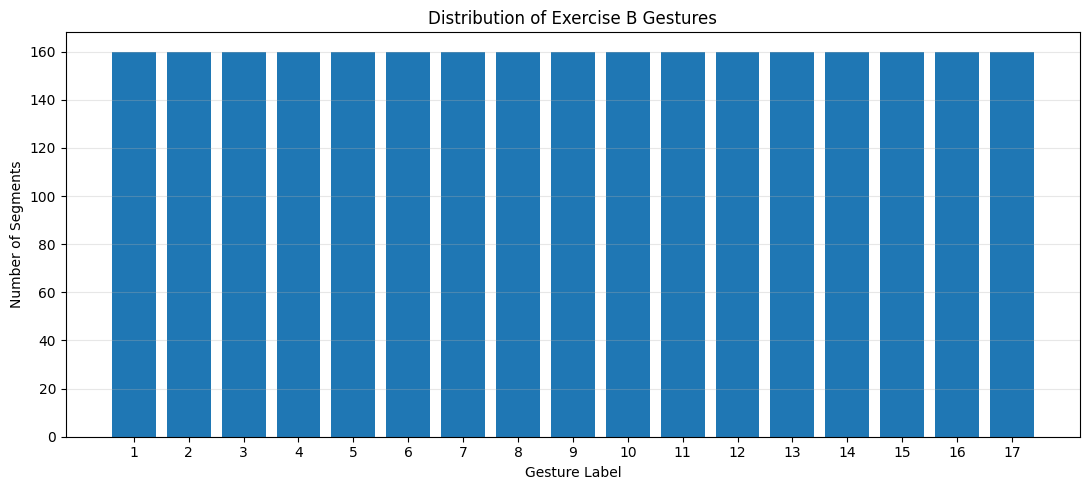

Repetition Distribution:


,Repetition,Segment_Count
0,1,680
1,3,680
2,4,680
3,6,680


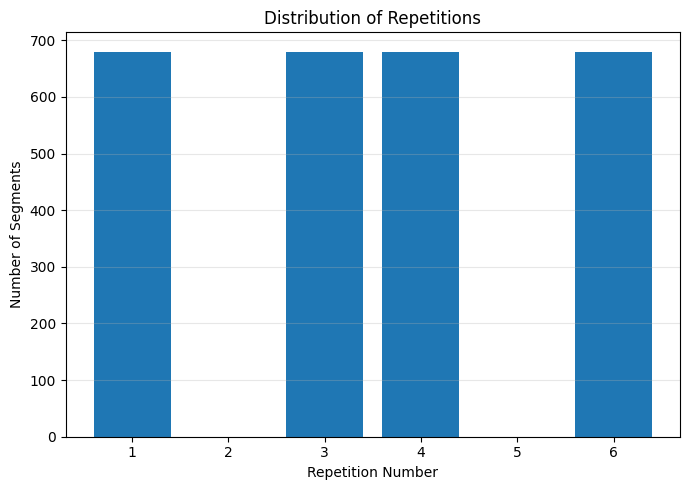

In [7]:
gesture_counts = (
    segment_df
    .groupby("Gesture")
    .size()
    .reset_index(name="Segment_Count")
)

repetition_counts = (
    segment_df
    .groupby("Repetition")
    .size()
    .reset_index(name="Segment_Count")
)

print("Gesture Distribution:")
display(gesture_counts)

plt.figure(figsize=(11, 5))
plt.bar(
    gesture_counts["Gesture"],
    gesture_counts["Segment_Count"]
)
plt.title("Distribution of Exercise B Gestures")
plt.xlabel("Gesture Label")
plt.ylabel("Number of Segments")
plt.xticks(range(1, 18))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


print("Repetition Distribution:")
display(repetition_counts)

plt.figure(figsize=(7, 5))
plt.bar(
    repetition_counts["Repetition"],
    repetition_counts["Segment_Count"]
)
plt.title("Distribution of Repetitions")
plt.xlabel("Repetition Number")
plt.ylabel("Number of Segments")
plt.xticks(range(1, 7))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Raw 12-Channel sEMG Signal

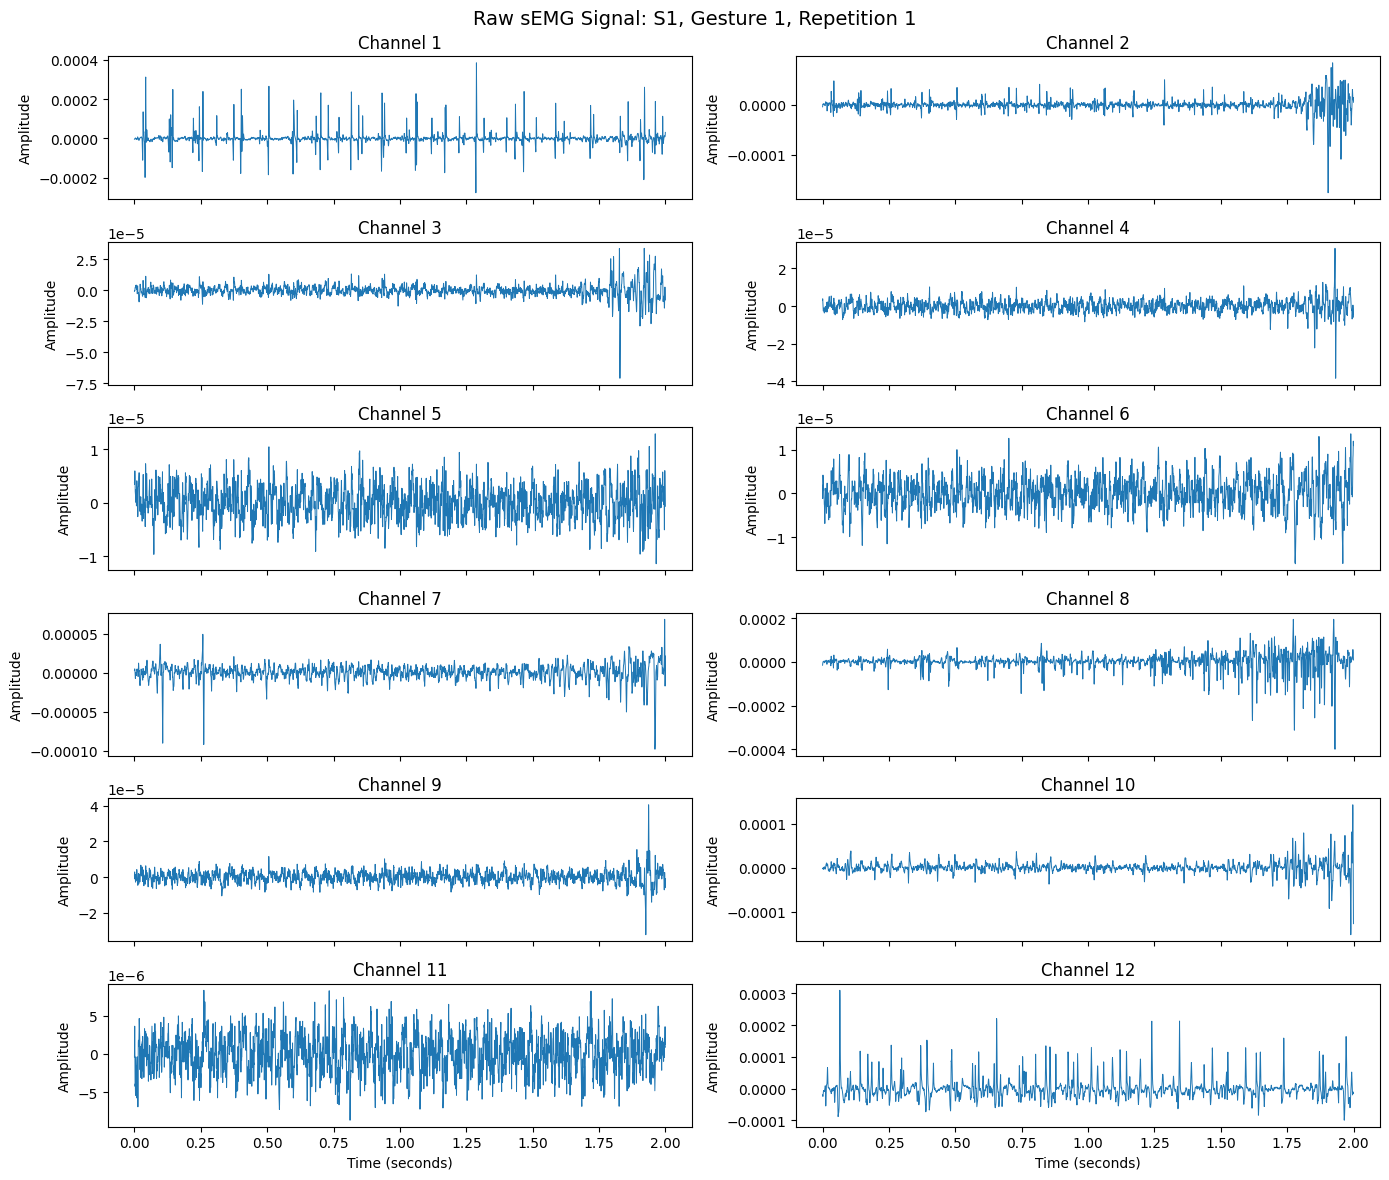

In [8]:
signal = waveform_example[:2 * SAMPLING_RATE]

time = np.arange(len(signal)) / SAMPLING_RATE

fig, axes = plt.subplots(
    6,
    2,
    figsize=(14, 12),
    sharex=True
)

for channel, ax in enumerate(axes.flat):
    ax.plot(
        time,
        signal[:, channel],
        linewidth=0.7
    )

    ax.set_title(f"Channel {channel + 1}")
    ax.set_ylabel("Amplitude")

for ax in axes[-1]:
    ax.set_xlabel("Time (seconds)")

fig.suptitle(
    "Raw sEMG Signal: S1, Gesture 1, Repetition 1",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Analyze Channel-wise and Subject-wise RMS Variation
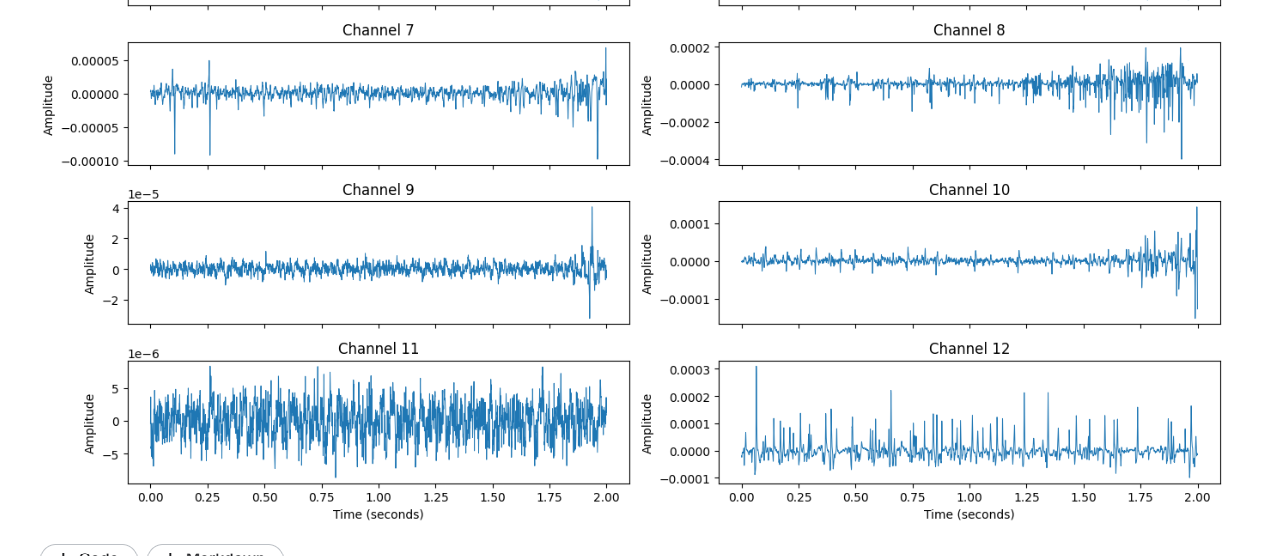

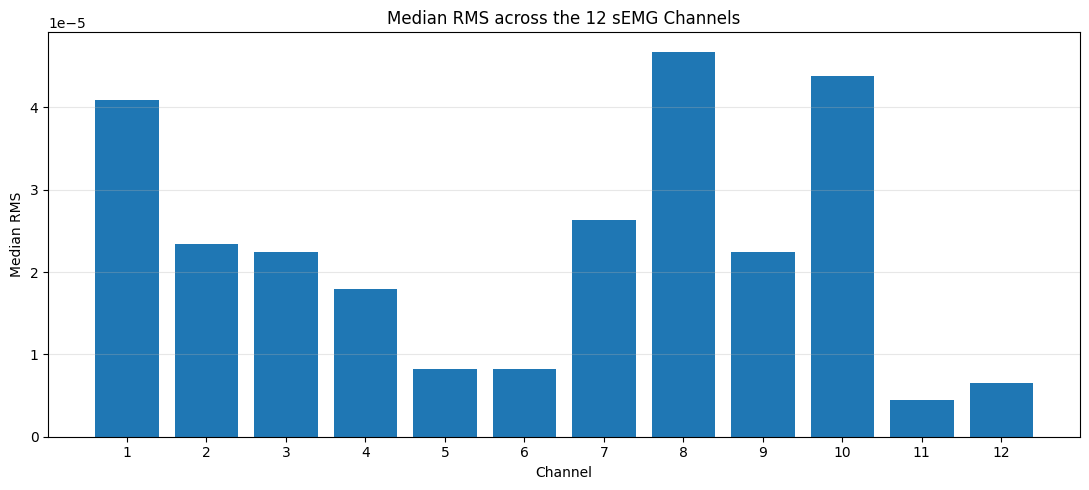

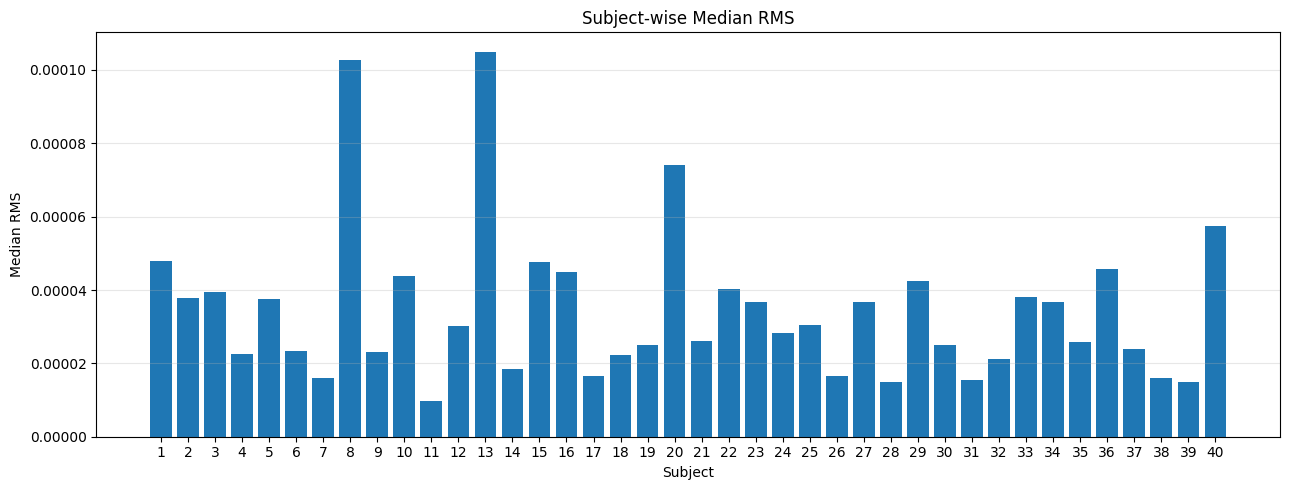

Channel with highest median RMS: RMS_Ch8
Channel with lowest median RMS: RMS_Ch11


In [9]:
rms_columns = [
    f"RMS_Ch{channel}"
    for channel in range(1, 13)
]

channel_median_rms = segment_df[
    rms_columns
].median()

plt.figure(figsize=(11, 5))

plt.bar(
    range(1, 13),
    channel_median_rms.values
)

plt.title("Median RMS across the 12 sEMG Channels")
plt.xlabel("Channel")
plt.ylabel("Median RMS")
plt.xticks(range(1, 13))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


subject_median_rms = (
    segment_df
    .groupby("Subject")["Mean_RMS"]
    .median()
)

plt.figure(figsize=(13, 5))

plt.bar(
    subject_median_rms.index,
    subject_median_rms.values
)

plt.title("Subject-wise Median RMS")
plt.xlabel("Subject")
plt.ylabel("Median RMS")
plt.xticks(range(1, 41))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


print(
    "Channel with highest median RMS:",
    channel_median_rms.idxmax()
)

print(
    "Channel with lowest median RMS:",
    channel_median_rms.idxmin()
)

# Final EDA Summary and Findings

In [10]:
final_summary = pd.DataFrame({
    "Item": [
        "Dataset",
        "Exercise",
        "EDA Subjects",
        "Training Repetitions",
        "Fixed Test Repetitions",
        "sEMG Channels",
        "Active Gestures",
        "Training Repetition Count",
        "Total Active Training Segments",
        "Missing Values",
        "Infinite Values",
        "Training Segments per Gesture",
        "Highest Median RMS Channel",
        "Lowest Median RMS Channel"
    ],
    "Result": [
        "NinaPro DB2",
        "Exercise B (E1)",
        "S1-S40",
        "1, 3, 4, 6",
        "2, 5 (Untouched)",
        12,
        segment_df["Gesture"].nunique(),
        segment_df["Repetition"].nunique(),
        len(segment_df),
        quality_df["Missing_Values"].sum(),
        quality_df["Infinite_Values"].sum(),
        gesture_counts["Segment_Count"].unique()[0],
        channel_median_rms.idxmax(),
        channel_median_rms.idxmin()
    ]
})

display(final_summary)

print("Final Findings")
print("--------------")

print(
    "1. The EDA used only Exercise B training repetitions 1, 3, 4 and 6 "
    "from subjects S1-S40."
)

print(
    "2. Repetitions 2 and 5 were reserved as the fixed test set "
    "and were not used during EDA."
)

print(
    "3. All 40 EDA subjects contain 12 sEMG channels, "
    "17 active gestures and 4 training repetitions."
)

print(
    "4. No missing or infinite EMG values were found in the training repetitions."
)

print(
    f"5. Each gesture contains {gesture_counts['Segment_Count'].unique()[0]} training segments, "
    "showing a balanced gesture-level distribution."
)

print(
    "6. The raw signal patterns and RMS values vary across channels."
)

print(
    "7. RMS values also vary across subjects, indicating "
    "inter-subject variability."
)

print(
    f"8. {channel_median_rms.idxmax()} has the highest median RMS, "
    f"while {channel_median_rms.idxmin()} has the lowest."
)


,Item,Result
0,Dataset,NinaPro DB2
1,Exercise,Exercise B (E1)
2,EDA Subjects,S1-S40
3,Training Repetitions,"1, 3, 4, 6"
4,Fixed Test Repetitions,"2, 5 (Untouched)"
5,sEMG Channels,12
6,Active Gestures,17
7,Training Repetition Count,4
8,Total Active Training Segments,2720
9,Missing Values,0


Final Findings
--------------
1. The EDA used only Exercise B training repetitions 1, 3, 4 and 6 from subjects S1-S40.
2. Repetitions 2 and 5 were reserved as the fixed test set and were not used during EDA.
3. All 40 EDA subjects contain 12 sEMG channels, 17 active gestures and 4 training repetitions.
4. No missing or infinite EMG values were found in the training repetitions.
5. Each gesture contains 160 training segments, showing a balanced gesture-level distribution.
6. The raw signal patterns and RMS values vary across channels.
7. RMS values also vary across subjects, indicating inter-subject variability.
8. RMS_Ch8 has the highest median RMS, while RMS_Ch11 has the lowest.
